In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import matplotlib.lines as mlines

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
import statsmodels.stats.multitest as smm

In [2]:
# Read in clustering results
cells = pd.read_csv('../data/t_cell_panel_clustering_results_patient_updated.csv', index_col=0)

# # Delete spare progression sample (there was a second later measurement which was associated with progression)
# # Delete sample 61290 006 as the patient went off trial due to participant preference
cells = cells.loc[cells['FlowSOM_metacluster_V1'] != 'P02_SPD_T_Cell_Panel',:]
cells = cells.loc[~cells['FlowSOM_metacluster_V1'].str.contains('P26'),:]
cells['FlowSOM_metacluster_V1'] = cells['FlowSOM_metacluster_V1'].str.replace('P02_SPD_2_T_Cell_Panel', 'P02_SPD_T_Cell_Panel')

# # Delete the following samples as they have only a single measurement
cells = cells.loc[~cells['FlowSOM_metacluster_V1'].str.contains('P27'),:]
cells = cells.loc[~cells['FlowSOM_metacluster_V1'].str.contains('P15'),:]
print(cells.shape)

(113, 41)


In [3]:
cells

,FlowSOM_metacluster_V1,FlowSOM_metacluster_1,FlowSOM_metacluster_10,FlowSOM_metacluster_11,FlowSOM_metacluster_12,FlowSOM_metacluster_13,FlowSOM_metacluster_14,FlowSOM_metacluster_15,FlowSOM_metacluster_16,FlowSOM_metacluster_17,...,FlowSOM_metacluster_37,FlowSOM_metacluster_38,FlowSOM_metacluster_39,FlowSOM_metacluster_4,FlowSOM_metacluster_40,FlowSOM_metacluster_5,FlowSOM_metacluster_6,FlowSOM_metacluster_7,FlowSOM_metacluster_8,FlowSOM_metacluster_9
0,P08_C1_D8_T_Cell_Panel,0,7662,993,2832,474,754,12,74,270,...,39,296,3235,3511,186,376,2504,904,385,283
1,P08_C7_D1_T_Cell_Panel,0,3073,106,1145,155,329,3,15,56,...,3,26,457,528,20,133,444,261,58,137
2,P08_C7_D22_T_Cell_Panel,0,3915,3,506,412,31,1,0,2,...,9,16,309,270,17,34,21,10,2,13
3,P08_SPD_T_Cell_Panel,0,4298,7,485,378,50,2,1,1,...,5,27,443,563,17,35,33,19,4,29
4,P24_C1_D1_T_Cell_Panel,0,6951,10,2831,565,84,43,0,2,...,3928,3298,273,220,192,63,803,57,73,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,Control_4_T_Cell_Panel,23800,50810,156,11888,1765,1949,1540,79,72,...,20055,5956,3533,13099,11237,146,477,128,5861,206
114,Control_12_T_Cell_Panel,0,7689,160,474,105,16,20,4,12,...,54,190,696,2014,28,73,902,15,30,16
115,Control_11_T_Cell_Panel,0,7770,202,454,91,17,23,10,11,...,8,47,732,2075,26,62,506,14,67,27
116,Control_3_T_Cell_Panel,2911,4251,0,1580,111,3,13,0,1,...,75,693,227,35674,75,45,1322,25,273,8


In [4]:
# Read in a table which describes the changes
cell_types = pd.read_csv('../data/t_cell_clsuters_2025_05_20.csv', index_col = 0)
cell_type_dict = dict(zip(cell_types['cluster'], cell_types['cell_type']))
cell_type_dict


cell_type_dict1 = {}
for x, y in cell_type_dict.items():
    if y in cell_type_dict1:
        # If y already exists as a key, append the new x value to its list
        if isinstance(cell_type_dict1[y], list):
            cell_type_dict1[y].append(str(x))
        else:
            # Convert existing single value to list
            cell_type_dict1[y] = [cell_type_dict1[y], str(x)]
    else:
        # If y is not yet a key, add it with x as its value
        cell_type_dict1[y] = str(x)
cell_type_dict1

{'B cell': '4',
 'Cytokine NK Cell': ['23', '21'],
 'Cytotoxic NK Cell': ['24', '28', '33', '34', '35', '22', '29', '37'],
 'Plasma cell': '14',
 'CD4_T_cell': '10',
 'Treg': ['13', '20'],
 'Cytotoxic_CD4': ['39', '40'],
 'CD56_Myeloid': ['5', '6'],
 'CD8_T_cell': ['12', '27', '31'],
 'Cytotoxic CD56+ CD8 T cell': ['30', '26'],
 'Cytotoxic CD8': ['32', '36', '38', '19', '25'],
 'Monocytes': ['1', '2', '15'],
 'HSPCs': '3',
 'Immature myeloid': '8',
 'Neutrophils': ['7', '9', '11', '16', '17'],
 'CD56+ CD8 T cell': '18'}

In [5]:
# Edit columns so that I can use the dictionaries to sum the desired columns together
cells.columns = cells.columns.str.replace('FlowSOM_metacluster_', '')

In [6]:
# Sum the columns of interest together
for cell_type, columns in cell_type_dict1.items():
    # Convert columns to list if it's not already
    col_list = columns if isinstance(columns, list) else [columns]
    # Sum the specified columns and create new column named after the cell type
    cells[cell_type] = cells[col_list].sum(axis=1)

In [7]:
# Delete the spare columns
cells = cells.drop(['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19',
       '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3',
       '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40',
       '5', '6', '7', '8', '9',], axis = 1)
cells.columns

Index(['V1', 'B cell', 'Cytokine NK Cell', 'Cytotoxic NK Cell', 'Plasma cell',
       'CD4_T_cell', 'Treg', 'Cytotoxic_CD4', 'CD56_Myeloid', 'CD8_T_cell',
       'Cytotoxic CD56+ CD8 T cell', 'Cytotoxic CD8', 'Monocytes', 'HSPCs',
       'Immature myeloid', 'Neutrophils', 'CD56+ CD8 T cell'],
      dtype='object')

In [8]:
# Add a column which details total T cells
cells['Total_T_cells'] = cells['CD4_T_cell'] + cells['Treg'] + cells['Cytotoxic_CD4'] + cells['CD8_T_cell'] + cells['Cytotoxic CD56+ CD8 T cell'] + cells['Cytotoxic CD8'] + cells['CD56+ CD8 T cell']
cells['Total_NK'] = cells['Cytokine NK Cell'] + cells['Cytotoxic NK Cell']
cells.head()

,V1,B cell,Cytokine NK Cell,Cytotoxic NK Cell,Plasma cell,CD4_T_cell,Treg,Cytotoxic_CD4,CD56_Myeloid,CD8_T_cell,Cytotoxic CD56+ CD8 T cell,Cytotoxic CD8,Monocytes,HSPCs,Immature myeloid,Neutrophils,CD56+ CD8 T cell,Total_T_cells,Total_NK
0,P08_C1_D8_T_Cell_Panel,3511,1163,17029,754,7662,883,3421,2880,3273,1363,9061,9737,29051,385,2524,697,26360,18192
1,P08_C7_D1_T_Cell_Panel,528,213,2602,329,3073,347,477,577,1228,301,1440,1288,5517,58,575,282,7148,2815
2,P08_C7_D22_T_Cell_Panel,270,179,1900,31,3915,661,326,55,545,144,817,60,839,2,28,57,6465,2079
3,P08_SPD_T_Cell_Panel,563,186,2731,50,4298,835,460,68,578,236,1324,217,1400,4,57,66,7797,2917
4,P24_C1_D1_T_Cell_Panel,220,1483,4540,84,6951,760,465,866,2908,146,9210,2214,5246,73,79,43,20483,6023


In [9]:
cells['V1'].unique()

array(['P08_C1_D8_T_Cell_Panel', 'P08_C7_D1_T_Cell_Panel',
       'P08_C7_D22_T_Cell_Panel', 'P08_SPD_T_Cell_Panel',
       'P24_C1_D1_T_Cell_Panel', 'P24_C1_D8_T_Cell_Panel',
       'P24_C7_D1_T_Cell_Panel', 'P19_C1_D1_T_Cell_Panel',
       'P19_C1_D8_T_Cell_Panel', 'P19_C7_D1_T_Cell_Panel',
       'P19_C7_D22_T_Cell_Panel', 'P12_C12_D29_T_Cell_Panel',
       'P12_C1_D1_T_Cell_Panel', 'P12_C1_D8_T_Cell_Panel',
       'P12_C7_D22_T_Cell_Panel', 'P04_C12_D29_T_Cell_Panel',
       'P04_C1_D1_T_Cell_Panel', 'P04_C1_D8_T_Cell_Panel',
       'P04_C7_D22_T_Cell_Panel', 'P03_C12_D29_T_Cell_Panel',
       'P03_C1_D1_T_Cell_Panel', 'P03_C1_D8_T_Cell_Panel',
       'P03_C7_D1_T_Cell_Panel', 'P03_C7_D22_T_Cell_Panel',
       'P38_C1_D1_T_Cell_Panel', 'P38_C1_D8_T_Cell_Panel',
       'P06_C12_D29_T_Cell_Panel', 'P06_C7_D1_T_Cell_Panel',
       'P06_C7_D22_T_Cell_Panel', 'P10_C12_D29_T_Cell_Panel',
       'P10_C1_D1_T_Cell_Panel', 'P10_C1_D8_T_Cell_Panel',
       'P10_C7_D1_T_Cell_Panel', 'P10_C7_D

In [10]:
#
pid_dict = {}
for i in cells['V1'].unique():
    if i.startswith('P'):
        x = i.split('_')[0]
        pid_dict[i] = x
    elif 'Control' in i:
        pid_dict[i] = i.replace('_T_Cell_Panel', '')

timepoint_dict = {}
for i in cells['V1'].unique():
    if i.startswith('Control'):
        timepoint_dict[i] = 'Control'
    elif i.startswith('P'):
        x = '_'.join(i.replace('_T_Cell_Panel', '').split('_')[1:])
        timepoint_dict[i] = x

cells['pid'] = cells['V1'].map(pid_dict)
cells['timepoint'] = cells['V1'].map(timepoint_dict)

In [11]:
cells

,V1,B cell,Cytokine NK Cell,Cytotoxic NK Cell,Plasma cell,CD4_T_cell,Treg,Cytotoxic_CD4,CD56_Myeloid,CD8_T_cell,...,Cytotoxic CD8,Monocytes,HSPCs,Immature myeloid,Neutrophils,CD56+ CD8 T cell,Total_T_cells,Total_NK,pid,timepoint
0,P08_C1_D8_T_Cell_Panel,3511,1163,17029,754,7662,883,3421,2880,3273,...,9061,9737,29051,385,2524,697,26360,18192,P08,C1_D8
1,P08_C7_D1_T_Cell_Panel,528,213,2602,329,3073,347,477,577,1228,...,1440,1288,5517,58,575,282,7148,2815,P08,C7_D1
2,P08_C7_D22_T_Cell_Panel,270,179,1900,31,3915,661,326,55,545,...,817,60,839,2,28,57,6465,2079,P08,C7_D22
3,P08_SPD_T_Cell_Panel,563,186,2731,50,4298,835,460,68,578,...,1324,217,1400,4,57,66,7797,2917,P08,SPD
4,P24_C1_D1_T_Cell_Panel,220,1483,4540,84,6951,760,465,866,2908,...,9210,2214,5246,73,79,43,20483,6023,P24,C1_D1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,Control_4_T_Cell_Panel,13099,4719,21288,1949,50810,2642,14770,623,12759,...,13871,47778,22280,5861,641,2887,101882,26007,Control_4,Control
114,Control_12_T_Cell_Panel,2014,102,2094,16,7689,347,724,975,550,...,4108,1467,1280,30,207,95,14128,2196,Control_12,Control
115,Control_11_T_Cell_Panel,2075,81,2119,17,7770,305,758,568,526,...,3979,1375,1586,67,264,67,14161,2200,Control_11,Control
116,Control_3_T_Cell_Panel,35674,120,188,3,4251,196,302,1367,1636,...,2864,43451,3175,273,34,829,11882,308,Control_3,Control


In [12]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
patient_info['PID'] = patient_info['PID'].astype(str)

# Create dictionaries so that I can add information to the dataframe such as 
# diagnosis and clinical outcomes

diagnosis_dx = dict(zip(patient_info['PID'], patient_info['Diagnosis']))

outcome_C6_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']))

outcome_C12_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C12_CC486']))

In [13]:
# Use the dictionaries to add clinical outcomes to the dataframe
cells['diagnosis'] = cells['pid'].map(diagnosis_dx)
cells['outcome_6'] = cells['pid'].map(outcome_C6_dx)
cells['outcome_12'] = cells['pid'].map(outcome_C12_dx)
cells

pid_timepoint = [(x + '_' + y.replace('_', '')) if 'P' in x else x for x, y in zip(cells['pid'], cells['timepoint'])]

cells['pid_timepoint'] = pid_timepoint
cells['pid_timepoint'] = cells['pid_timepoint'].astype(str)

In [14]:
# Read in data from Julie. This dataframe contains the patient outcomes and time when a sample was collected 
timepoints = pd.read_excel('../data/MS_flow_outcome_dx_clean_updatedJan24_patient_updated.xlsx')
timepoints['PID_Timepoint'] = timepoints['PID'].astype(str) + '_' + timepoints['Cycle_day']
to_keep = ['Cycle_day', 'Day_since_C1D1', 'Day_since_scr', 'PID_Timepoint']
timepoints = timepoints.loc[:,timepoints.columns.isin(to_keep)]
timepoints.head()
cells1 = pd.merge(cells, timepoints, left_on='pid_timepoint', right_on= 'PID_Timepoint', how = 'left')

# Update the clinical outcomes and diagnosis columns to reflect that there are healthy samples in the sample set
diagnosis = ['Healthy' if 'Healthy' in x else y for x, y in zip(cells['pid'], cells['diagnosis'])]
        
outcome_6 = ['Healthy' if 'Healthy' in x else y for x, y in zip(cells['pid'], cells['outcome_6'])]

outcome_12 = ['Healthy' if 'Healthy' in x else y for x, y in zip(cells['pid'], cells['outcome_12'])]
        
cells1['diagnosis'] = diagnosis
cells1['outcome_6'] = outcome_6
cells1['outcome_12'] = outcome_12

In [15]:
cells1

,V1,B cell,Cytokine NK Cell,Cytotoxic NK Cell,Plasma cell,CD4_T_cell,Treg,Cytotoxic_CD4,CD56_Myeloid,CD8_T_cell,...,pid,timepoint,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint
0,P08_C1_D8_T_Cell_Panel,3511,1163,17029,754,7662,883,3421,2880,3273,...,P08,C1_D8,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8
1,P08_C7_D1_T_Cell_Panel,528,213,2602,329,3073,347,477,577,1228,...,P08,C7_D1,MDS,non-responder_2,non-responder_2,P08_C7D1,C7D1,217.0,243.0,P08_C7D1
2,P08_C7_D22_T_Cell_Panel,270,179,1900,31,3915,661,326,55,545,...,P08,C7_D22,MDS,non-responder_2,non-responder_2,P08_C7D22,C7D22,238.0,264.0,P08_C7D22
3,P08_SPD_T_Cell_Panel,563,186,2731,50,4298,835,460,68,578,...,P08,SPD,MDS,non-responder_2,non-responder_2,P08_SPD,NaN,NaN,NaN,NaN
4,P24_C1_D1_T_Cell_Panel,220,1483,4540,84,6951,760,465,866,2908,...,P24,C1_D1,AML,non-responder_2,NaN,P24_C1D1,C1D1,0.0,21.0,P24_C1D1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,Control_4_T_Cell_Panel,13099,4719,21288,1949,50810,2642,14770,623,12759,...,Control_4,Control,NaN,NaN,NaN,Control_4,NaN,NaN,NaN,NaN
109,Control_12_T_Cell_Panel,2014,102,2094,16,7689,347,724,975,550,...,Control_12,Control,NaN,NaN,NaN,Control_12,NaN,NaN,NaN,NaN
110,Control_11_T_Cell_Panel,2075,81,2119,17,7770,305,758,568,526,...,Control_11,Control,NaN,NaN,NaN,Control_11,NaN,NaN,NaN,NaN
111,Control_3_T_Cell_Panel,35674,120,188,3,4251,196,302,1367,1636,...,Control_3,Control,NaN,NaN,NaN,Control_3,NaN,NaN,NaN,NaN


In [16]:
# Create a list so that I can delete the samples where I acquired a C7D22 but the patient dropped out for
# reasons unrelated to the disease or treatment note that these patients have an NA in the outcome_12 column

time_to_keep = ['non-responder_2', 'responder_1', 'Healthy']

to_del = [x for x, y in zip(cells1['pid_timepoint'], cells1['outcome_12']) 
          if 'C7D22' in x and y not in time_to_keep]

to_del
print(cells1.shape)
cells1 = cells1.loc[~cells1['PID_Timepoint'].isin(to_del), :]
print(cells1.shape)

(113, 29)
(111, 29)


In [17]:
# Sum columns and then delete the spare columns
cells1.shape
cells1['cell_number'] = cells1.loc[:,'B cell':'CD56+ CD8 T cell'].sum(axis=1)

print(cells1.shape)

(111, 30)


/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_35344/923081539.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells1['cell_number'] = cells1.loc[:,'B cell':'CD56+ CD8 T cell'].sum(axis=1)


In [18]:
# Read in a dataframe which details the number of myeloid cells 
# so that I can figure out how to control for the number of stem and progenitor cells in each sample
hspc = pd.read_csv('../data/myeloid_panel_patient_metacluster_table_patient_updated.csv', index_col=0)
hspc['total_cells'] = hspc.loc[:, 'metacluster_1':'metacluster_9'].sum(axis = 1) #'metacluster_1''metacluster_2' metacluster_3 metacluster_9

hspc['hspc_lsc'] = hspc[['metacluster_1', 'metacluster_2', 'metacluster_3', 'metacluster_9']].sum(axis=1) # these coliumns are HSPC and aberrant
#hspc['hspc_lsc'] = hspc.loc[:, 'metacluster_1':'CD123_LSC'].sum(axis =1)
hspc['ratio_hspc_lsc'] = hspc.loc[:, 'hspc_lsc'].divide(hspc.loc[:, 'total_cells'], axis =0)
hspc['multiplication_factor'] = 1 - hspc.loc[:, 'ratio_hspc_lsc'] 
hspc['PID_Timepoint'] = hspc['FileNames'].str.replace('_Myeloid_Panel', '').str.replace('_C1_', '_C1').str.replace('_C7_', '_C7').str.replace('_C12_', '_C12')
hspc = hspc.loc[:, ['PID_Timepoint', 'multiplication_factor']]
hspc

,PID_Timepoint,multiplication_factor
0,P08_C1D8,0.852736
1,P08_C7D1,0.866397
2,P08_C7D22,0.954610
3,P08_SPD,0.945232
4,P24_C1D1,0.654679
...,...,...
113,Control_4,0.987427
114,Control_12,0.990564
115,Control_11,0.991135
116,Control_3,0.988056


In [19]:
# Create new dataframe which contains the corrected number of cells
#(i.e after accounting for stem and progenitor cells)
cells_of_cd34_neg = pd.merge(cells1, hspc, left_on= 'pid_timepoint', right_on= 'PID_Timepoint')
cells_of_cd34_neg['corrected_cell_num'] = (cells_of_cd34_neg['cell_number'] * cells_of_cd34_neg['multiplication_factor']).astype(int)

best_outcome = []
for x, y, z in zip(cells_of_cd34_neg['outcome_6'], cells_of_cd34_neg['outcome_12'], cells_of_cd34_neg['pid']):
    if (x == 'responder_1') | (y == 'responder_1'):
        best_outcome.append('responder')
    elif (x == 'non-responder_2') | (y == 'non-responder_2'):
        best_outcome.append('non_responder')
    elif 'Control' in z:
        best_outcome.append('Control')
        
        
cells_of_cd34_neg['best_response'] = best_outcome

In [20]:
# Rename columns for easier plotting
cells_of_cd34_neg.columns = cells_of_cd34_neg.columns.str.replace('Cytotoxic_CD56', 'GzmB_pos_CD56').str.replace('+', '')
cells_of_cd34_neg.columns = cells_of_cd34_neg.columns.str.replace('Cytotoxic_CD8', 'GzmB_pos_CD8')
cells_of_cd34_neg.columns


Index(['V1', 'B cell', 'Cytokine NK Cell', 'Cytotoxic NK Cell', 'Plasma cell',
       'CD4_T_cell', 'Treg', 'Cytotoxic_CD4', 'CD56_Myeloid', 'CD8_T_cell',
       'Cytotoxic CD56 CD8 T cell', 'Cytotoxic CD8', 'Monocytes', 'HSPCs',
       'Immature myeloid', 'Neutrophils', 'CD56 CD8 T cell', 'Total_T_cells',
       'Total_NK', 'pid', 'timepoint', 'diagnosis', 'outcome_6', 'outcome_12',
       'pid_timepoint', 'Cycle_day', 'Day_since_C1D1', 'Day_since_scr',
       'PID_Timepoint_x', 'cell_number', 'PID_Timepoint_y',
       'multiplication_factor', 'corrected_cell_num', 'best_response'],
      dtype='object')

In [21]:
# Read in the p-values which Jake sent to me
pval = pd.read_excel('../data/2024_11_08_pvalues_from_Jake.xlsx', sheet_name = 't_cell_panel')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('TREG', 'Treg_x')

pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('Plasma_Cell', 'Plasma cell')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('CD4_T_Cell', 'CD4_T_cell')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('CYTOKINE_NK_CELL', 'Cytokine_NK_Cell')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('Cytotoxic_NK_cell', 'Cytotoxic_NK_Cell')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('CD8_T_Cell', 'CD8_T_cell')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('GZMB_POS_CD56_CD8_T_CELL', 'GzmB_pos_CD56_CD8_T_cell')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('GZMB_POS_CD8', 'GzmB_pos_CD8')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('HSPCS', 'HSPCs')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('MONOCYTES', 'Monocytes')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('IMMATURE_MYELOID', 'Immature_myeloid')

pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('CD56_CD8_T_CELL', 'CD56_CD8_T_cell')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('TOTAL_T_CELLS', 'Total_T_cells')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('TOTAL_NK', 'Total_NK')
pval['Cluster_Cell_type'] = pval['Cluster_Cell_type'].str.replace('CYTOTOXIC_CD4_T_CELL', 'Cytotoxic CD4 T cell')

for i in pval['Cluster_Cell_type']:
    if i not in cells_of_cd34_neg.columns:
        print(i)

Cytotoxic CD4 T cell
Treg_x
B_cell
Cytotoxic_NK_Cell
Cytokine_NK_Cell
GzmB_pos_CD56_CD8_T_cell
GzmB_pos_CD8
Immature_myeloid
CD56_CD8_T_cell
WORK.CYTOTOXIC_CD4


In [22]:
# Map the timepoints to each columns
timepoint_dict = {'C1_D1' : 2, 'C1_D8' : 3, 'C7_D1': 4, 'C7_D22' : 5, 'C12_D29' : 6, 'SPD' : 7, 'Control': 1}
cells_of_cd34_neg['time1'] = cells_of_cd34_neg['timepoint'].map(timepoint_dict)

In [23]:
for x, y in enumerate(cells_of_cd34_neg.columns):
    print(x, y)

0 V1
1 B cell
2 Cytokine NK Cell
3 Cytotoxic NK Cell
4 Plasma cell
5 CD4_T_cell
6 Treg
7 Cytotoxic_CD4
8 CD56_Myeloid
9 CD8_T_cell
10 Cytotoxic CD56 CD8 T cell
11 Cytotoxic CD8
12 Monocytes
13 HSPCs
14 Immature myeloid
15 Neutrophils
16 CD56 CD8 T cell
17 Total_T_cells
18 Total_NK
19 pid
20 timepoint
21 diagnosis
22 outcome_6
23 outcome_12
24 pid_timepoint
25 Cycle_day
26 Day_since_C1D1
27 Day_since_scr
28 PID_Timepoint_x
29 cell_number
30 PID_Timepoint_y
31 multiplication_factor
32 corrected_cell_num
33 best_response
34 time1


In [24]:
cells_of_cd34_neg.iloc[:, list(range(1,12)) + list(range(14,18))] = cells_of_cd34_neg.iloc[:, list(range(1,12)) + list(range(14,18))].divide(cells_of_cd34_neg.loc[:, 'corrected_cell_num'], axis =0) *100
cells_of_cd34_neg.loc[:, 'HSPCs'] = cells_of_cd34_neg.loc[:, 'HSPCs'].divide(cells_of_cd34_neg.loc[:, 'cell_number'], axis =0) *100
cells_of_cd34_neg

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_35344/3754268920.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       4.408589
1       3.235691
2       2.877851
3       4.556122
4       0.952299
         ...    
106     6.026630
107     9.112298
108     9.382772
109    37.544465
110     7.924196
Name: B cell, Length: 111, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cells_of_cd34_neg.iloc[:, list(range(1,12)) + list(range(14,18))] = cells_of_cd34_neg.iloc[:, list(range(1,12)) + list(range(14,18))].divide(cells_of_cd34_neg.loc[:, 'corrected_cell_num'], axis =0) *100
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_35344/3754268920.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      1.460321
1      1.305307
2      1.907909
3      1.505220
4      6.41935

,V1,B cell,Cytokine NK Cell,Cytotoxic NK Cell,Plasma cell,CD4_T_cell,Treg,Cytotoxic_CD4,CD56_Myeloid,CD8_T_cell,...,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint_x,cell_number,PID_Timepoint_y,multiplication_factor,corrected_cell_num,best_response,time1
0,P08_C1_D8_T_Cell_Panel,4.408589,1.460321,21.382471,0.946760,9.620794,1.108739,4.295580,3.616273,4.109744,...,C1D8,9.0,35.0,P08_C1D8,93394,P08_C1D8,0.852736,79640,non_responder,3
1,P08_C7_D1_T_Cell_Panel,3.235691,1.305307,15.945582,2.016178,18.831965,2.126486,2.923152,3.535973,7.525432,...,C7D1,217.0,243.0,P08_C7D1,18835,P08_C7D1,0.866397,16318,non_responder,4
2,P08_C7_D22_T_Cell_Panel,2.877851,1.907909,20.251546,0.330420,41.728842,7.045406,3.474739,0.586229,5.808996,...,C7D22,238.0,264.0,P08_C7D22,9829,P08_C7D22,0.954610,9382,non_responder,5
3,P08_SPD_T_Cell_Panel,4.556122,1.505220,22.100834,0.404629,34.781905,6.757304,3.722586,0.550295,4.677511,...,NaN,NaN,NaN,NaN,13073,P08_SPD,0.945232,12357,non_responder,7
4,P24_C1_D1_T_Cell_Panel,0.952299,6.419358,19.651978,0.363605,30.088304,3.289758,2.012813,3.748593,12.587655,...,C1D1,0.0,21.0,P24_C1D1,35288,P24_C1D1,0.654679,23102,non_responder,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,Control_4_T_Cell_Panel,6.026630,2.171133,9.794251,0.896702,23.376827,1.215540,6.795429,0.286632,5.870201,...,NaN,NaN,NaN,NaN,220120,Control_4,0.987427,217352,Control,1
107,Control_12_T_Cell_Panel,9.112298,0.461497,9.474256,0.072392,34.788707,1.569994,3.275722,4.411365,2.488463,...,NaN,NaN,NaN,NaN,22313,Control_12,0.990564,22102,Control,1
108,Control_11_T_Cell_Panel,9.382772,0.366267,9.581732,0.076871,35.134524,1.379154,3.427538,2.568392,2.378476,...,NaN,NaN,NaN,NaN,22313,Control_11,0.991135,22115,Control,1
109,Control_3_T_Cell_Panel,37.544465,0.126292,0.197857,0.003157,4.473889,0.206277,0.317835,1.438675,1.721779,...,NaN,NaN,NaN,NaN,96167,Control_3,0.988056,95018,Control,1


In [25]:
cells_of_cd34_neg['pid']

0             P08
1             P08
2             P08
3             P08
4             P24
          ...    
106     Control_4
107    Control_12
108    Control_11
109     Control_3
110     Control_2
Name: pid, Length: 111, dtype: object

In [26]:
cells_of_cd34_neg.columns

Index(['V1', 'B cell', 'Cytokine NK Cell', 'Cytotoxic NK Cell', 'Plasma cell',
       'CD4_T_cell', 'Treg', 'Cytotoxic_CD4', 'CD56_Myeloid', 'CD8_T_cell',
       'Cytotoxic CD56 CD8 T cell', 'Cytotoxic CD8', 'Monocytes', 'HSPCs',
       'Immature myeloid', 'Neutrophils', 'CD56 CD8 T cell', 'Total_T_cells',
       'Total_NK', 'pid', 'timepoint', 'diagnosis', 'outcome_6', 'outcome_12',
       'pid_timepoint', 'Cycle_day', 'Day_since_C1D1', 'Day_since_scr',
       'PID_Timepoint_x', 'cell_number', 'PID_Timepoint_y',
       'multiplication_factor', 'corrected_cell_num', 'best_response',
       'time1'],
      dtype='object')

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_35344/375798686.py:41: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data = cells_of_cd34_neg1, x = 'time1', y = cells_of_cd34_neg1.loc[:, figure_list[y]], err_style = 'bars',
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_35344/375798686.py:41: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data = cells_of_cd34_neg1, x = 'time1', y = cells_of_cd34_neg1.loc[:, figure_list[y]], err_style = 'bars',
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeErro

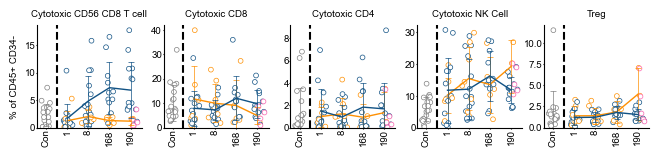

In [27]:
# Make a multiplot of all the graphs for the figure

# Set font
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text

color_dict = {'non_responder':'#fe9003', 'responder':'#115284', 'Control': 'grey'}

fig, axs = plt.subplots(nrows = 1, ncols = 5, figsize = (6.69 * 1, 6.69 * 0.25))
axs_flatten = axs.flatten()

stars = cells_of_cd34_neg.loc[cells_of_cd34_neg['timepoint'] == 'SPD', :]['pid'].str.replace('_', '').to_list()
               

figure_list = ['Cytotoxic CD56 CD8 T cell', 'Cytotoxic CD8', 'Cytotoxic_CD4', 'Cytotoxic NK Cell',  'Treg']
jitter_amount = 0.75  # Adjust the jitter amount as needed

x_jitter = np.random.normal(1, jitter_amount, size = cells_of_cd34_neg.shape[0])
timejitter =  []
for z, (w, x, y) in enumerate(zip(cells_of_cd34_neg['time1'], cells_of_cd34_neg['pid'], x_jitter)): 
    if (w == 5) & (x in stars): 
        timejitter.append(w + (y/10))
    elif z % 2 == 0:
        timejitter.append(w + (y/10))
    else:
        timejitter.append(w - (y/10))
cells_of_cd34_neg['time2'] = timejitter
stars1 = cells_of_cd34_neg.loc[(cells_of_cd34_neg['pid'].isin(stars)) &  (cells_of_cd34_neg['timepoint'] == 'C7_D22'), :]
cells_of_cd34_neg1 = cells_of_cd34_neg.loc[cells_of_cd34_neg['timepoint'] != 'SPD',:]
cells_of_cd34_neg1 = cells_of_cd34_neg1.loc[cells_of_cd34_neg1['timepoint'] != 'C12_D29',:]

for y, ax in enumerate(axs_flatten):
        ax.scatter(x = cells_of_cd34_neg1.loc[:,'time2'], y = cells_of_cd34_neg1.loc[:, figure_list[y]], 
              #c = cells_of_cd34_neg1.loc[:,'best_response'].map(color_dict), 
                   facecolor='white',          # Makes the fill white
                      edgecolor=cells_of_cd34_neg1.loc[:,'best_response'].map(color_dict),          # Makes the edge black
                      linewidth=0.5,    
                      alpha=1, 
                      s= 12, rasterized=True)
        sns.lineplot(data = cells_of_cd34_neg1, x = 'time1', y = cells_of_cd34_neg1.loc[:, figure_list[y]], err_style = 'bars',
                 ci = 'sd',  err_kws={'linewidth': 0.5, 'capsize':2, 'capthick': 0.5},
                     legend = False, hue = 'best_response', 
                 palette = color_dict, linewidth = 1, ax = ax)
        ax.scatter(x = stars1['time2'], y = stars1[figure_list[y]], s = 12,  facecolor='white',  linewidth=0.5, edgecolor = 'hotpink')
        
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_ylim(bottom = 0)
        e = str(figure_list[y])
        e = e.replace('_x', '')
        e = e.replace('GzmB_pos_CD56_CD8_T_cell', 'GzmB+_CD56+_CD8_T_cell')
        e = e.replace('GzmB_pos_CD8', 'GzmB+_CD8_T_cell')
        
        e = e.replace('_', ' ')
        
        ax.set_title(e, fontsize = 7)
        ax.axvline(1.5, color = 'black', ls = '--')
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.set_xticklabels(['Con', '1', '8', '168', '190'], rotation = 90, fontsize = 7)
        ax.set_xlabel(xlabel = '',  fontsize = 7)
        ax.set_ylim(bottom = 0)
        ax.tick_params(axis='both', labelsize=7, pad = 0.1, length = 1)
         # Get the axis limits
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()

        # Calculate position as a percentage of the axis range
        x_pos = xmin + 0.25 * (xmax - xmin)  # 50% from left
        y_pos = ymax - 0.1 * (ymax - ymin)  # 5% from top

#         text = pval.loc[pval['Cluster_Cell_type'] == figure_list[y], 'p_values'].iloc[0]
#         text = f'$\it{{p}} = {text}$'
#         ax.text(s = text, x = x_pos, y =  y_pos, fontsize = 7)
        
        if (y % 5 == 0):
            ax.set_ylabel('% of CD45+ CD34-', fontsize  =7)
        else:
            ax.set_ylabel('', fontsize  =7 )
plt.tight_layout(w_pad = 0.1)
#fig.savefig('for_main_figure.pdf', dpi = 600)